In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.model import fit_model, predict_match, print_prediction

df = pd.read_parquet(Path.cwd().parent / "data" / "matches.parquet")
model = fit_model(df)

# Rebuild the ratings DataFrame
params = model.params
attack, defense = {}, {}
for name, val in params.items():
    if name.startswith("team[T."):
        attack[name.replace("team[T.", "").rstrip("]")] = val
    elif name.startswith("opponent[T."):
        defense[name.replace("opponent[T.", "").rstrip("]")] = val

ratings = pd.DataFrame({"attack": attack, "defense": defense})
ratings["defense_strength"] = -ratings["defense"]
ratings = ratings.drop(columns=["defense"])
ratings["overall"] = ratings["attack"] + ratings["defense_strength"]

print(f"Ready: {len(ratings)} teams loaded")

Ready: 25 teams loaded


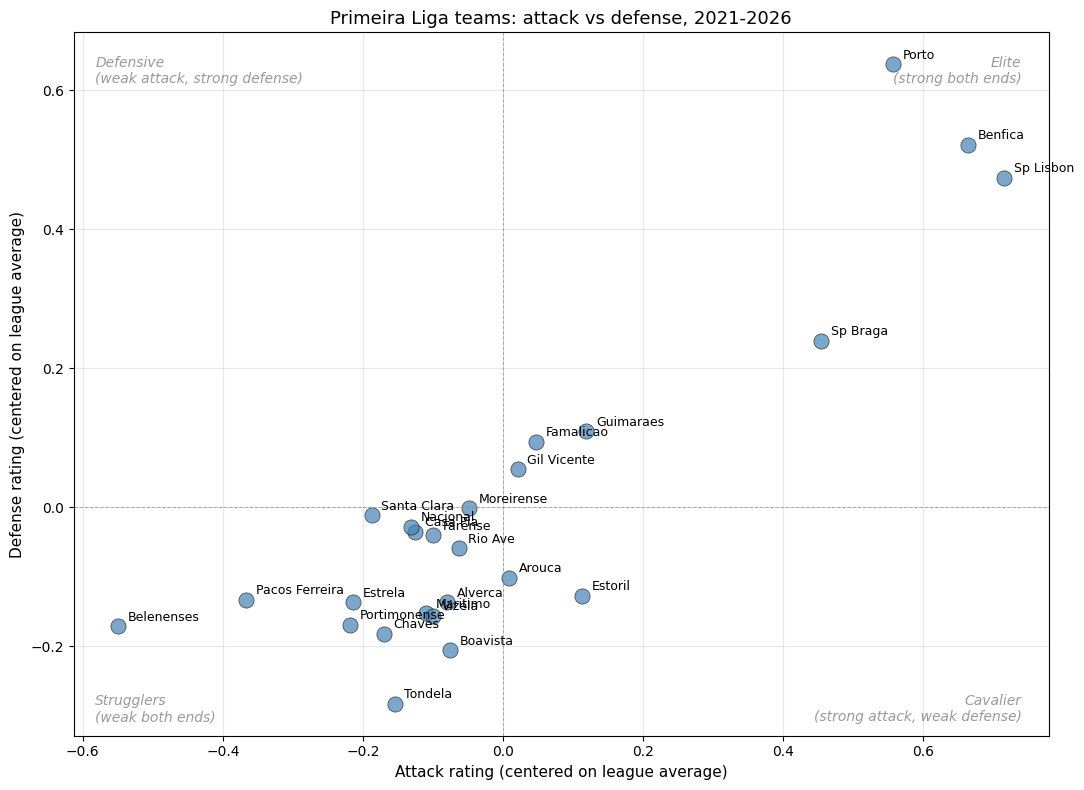

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Center ratings on the league mean so the axes are intuitive
plot_data = ratings.copy()
plot_data["attack_centered"] = plot_data["attack"] - plot_data["attack"].mean()
plot_data["defense_centered"] = plot_data["defense_strength"] - plot_data["defense_strength"].mean()

fig, ax = plt.subplots(figsize=(11, 8))

# Reference lines at the league average
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.6)

# Scatter all teams
ax.scatter(
    plot_data["attack_centered"],
    plot_data["defense_centered"],
    s=120,
    alpha=0.7,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5,
)

# Label each point with the team name
for team, row in plot_data.iterrows():
    ax.annotate(
        team,
        (row["attack_centered"], row["defense_centered"]),
        xytext=(7, 4),
        textcoords="offset points",
        fontsize=9,
    )

# Quadrant labels (in corners, faint)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[1] * 0.95, ylim[1] * 0.95, "Elite\n(strong both ends)",
        ha="right", va="top", fontsize=10, alpha=0.4, style="italic")
ax.text(xlim[0] * 0.95, ylim[1] * 0.95, "Defensive\n(weak attack, strong defense)",
        ha="left", va="top", fontsize=10, alpha=0.4, style="italic")
ax.text(xlim[1] * 0.95, ylim[0] * 0.95, "Cavalier\n(strong attack, weak defense)",
        ha="right", va="bottom", fontsize=10, alpha=0.4, style="italic")
ax.text(xlim[0] * 0.95, ylim[0] * 0.95, "Strugglers\n(weak both ends)",
        ha="left", va="bottom", fontsize=10, alpha=0.4, style="italic")

ax.set_xlabel("Attack rating (centered on league average)", fontsize=11)
ax.set_ylabel("Defense rating (centered on league average)", fontsize=11)
ax.set_title("Primeira Liga teams: attack vs defense, 2021-2026", fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(Path.cwd().parent / "data" / "team_ratings.png", dpi=150, bbox_inches="tight")
plt.show()